Felix Shyann- Z23813474
14 Jun 2026
CAP 5768 

In [1]:
import pandas as pd

df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [2]:
df[df.isna().any(axis=1)]  

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


In [3]:
#Contains no missing values per last cell

In [4]:
#Check for duplicates
df.duplicated().sum()

23899

In [5]:
#Previous code cell reflects that there are 23,899 duplicated rows. 
#The cell below this will delete the duplicates and keep the first instance of each.

In [6]:
df = df.drop_duplicates(keep='first')

In [7]:
#checking shape after deletion
df.shape 

(229781, 22)

In [8]:
# 253,680(Rows I started with) - 23,899(The duplicates) = 229,781(Row count that should be left)

#That row count is reflected above by df.shape

In [9]:
df.columns #I am checking to see column names so I dont have to scroll 

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [10]:
df = df.rename(columns ={"Sex":"Gender"}) #Renaming column name from sex to gender

In [11]:
df.dtypes #printing data types to check the types to convert one of them

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Gender                  float64
Age                     float64
Education               float64
Income                  float64
dtype: object

In [12]:
# Converting the Education variable to a different data type
df["Education"] = df["Education"].astype('category')

In [13]:
#Creating a new variable that I will use in my analysis
df['HealthyDiet'] = ((df['Fruits'] == 1) & (df['Veggies'] == 1)).astype(int)
df['HealthyDiet'].describe()

count    229781.000000
mean          0.535014
std           0.498774
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: HealthyDiet, dtype: float64

create two smaller dataframes based on a condition; individuals diets

In [14]:
#The smaller dfs
df_healthydiet = df[df['HealthyDiet'] == 1]
df_unhealthydiet = df[df['HealthyDiet'] == 0]
#verify
print(df_healthydiet.shape)
print(df_unhealthydiet.shape)

(122936, 23)
(106845, 23)


3A. Descriptive Statistics
•	Obtain the descriptive statistics of two numerical variables mean, median, std deviation, min, and max). Then, add a markdown cell and explain what you is observed from the obtained values. (2 points)
•	Get the category counts of at least two categorical variables. (2 points)
•	Get the average value for at least 2 numerical variables per category using the groupby() function. (2 points)


In [15]:
df['BMI'].describe()

count    229781.00000
mean         28.68567
std           6.78636
min          12.00000
25%          24.00000
50%          27.00000
75%          32.00000
max          98.00000
Name: BMI, dtype: float64

Observed: 50% of people have a BMI of 27 or lower, with the 'average' BMI of 28

In [16]:
df['PhysHlth'].describe()

count    229781.000000
mean          4.675178
std           9.046568
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max          30.000000
Name: PhysHlth, dtype: float64

Observed: The 'average' person said about 4 to 5 days they experienced bad physical health.
 and half said none

In [17]:
#Value counts:
df['HighBP'].value_counts()

HighBP
0.0    125359
1.0    104422
Name: count, dtype: int64

In [18]:
df['HighChol'].value_counts()

HighChol
0.0    128273
1.0    101508
Name: count, dtype: int64

In [19]:
df['HeartDiseaseorAttack'].value_counts()

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64

In [20]:
#groupby() to find avg value for atleast 2 numerical categories.(Note: its percentages)

In [21]:
df.columns[0]

'Diabetes_012'

In [22]:
# 0 = healthy, 1 = pre, 2 = Diabetic

In [23]:
df.groupby('Diabetes_012')['BMI'].mean()

Diabetes_012
0.0    28.030528
1.0    30.726075
2.0    31.964242
Name: BMI, dtype: float64

In [24]:
df.groupby('Diabetes_012')['PhysHlth'].mean()

Diabetes_012
0.0    4.018805
1.0    6.351048
2.0    8.008491
Name: PhysHlth, dtype: float64

In [25]:
df.groupby('Diabetes_012')['HeartDiseaseorAttack'].mean()

Diabetes_012
0.0    0.079961
1.0    0.143444
2.0    0.223837
Name: HeartDiseaseorAttack, dtype: float64

In [26]:
df.groupby('HeartDiseaseorAttack')['BMI'].mean()

HeartDiseaseorAttack
0.0    28.593748
1.0    29.484336
Name: BMI, dtype: float64

--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'count')

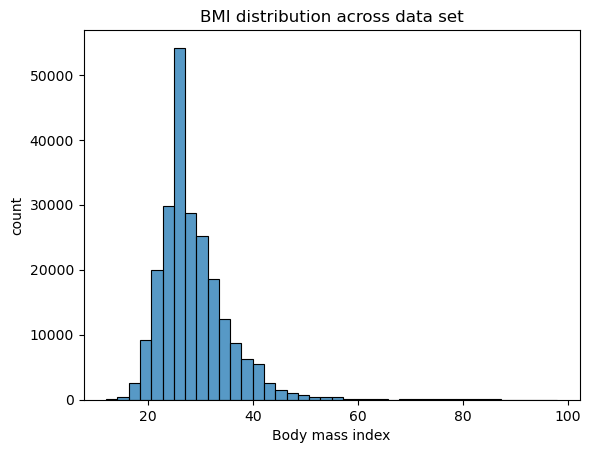

In [27]:

#histogram for BMI
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.histplot(data = df,x = "BMI", bins = 40 )
plt.title("BMI distribution across data set") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('Body mass index')
plt.ylabel('count')

 **OBSERVATION**

 This histogram shows that most participants have a BMI between
 20 and 40. The distribution is skewed to the right towards higher BMIs. 
 There are a few people with a BMI higher than roughly 60(Outliers). 
 In my research question, BMI is one specific number I am looking at, 
 by searching to see if it increases the risk of having diabetes. 

--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'count')

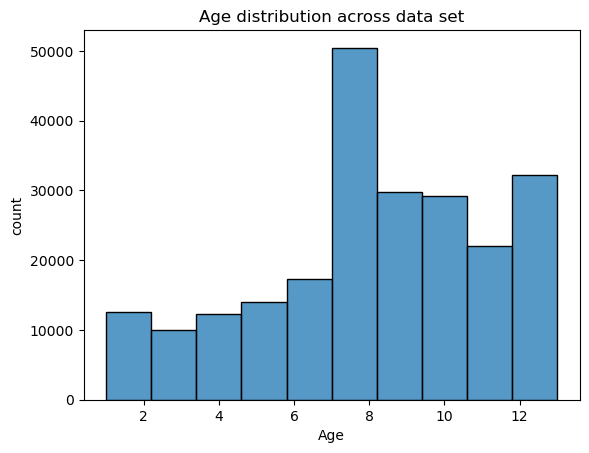

In [28]:
sns.histplot(data = df,x = "Age", bins = 10 )
plt.title("Age distribution across data set") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('Age')
plt.ylabel('count')

 age code breakdown found here: https://www.cdc.gov/brfss/annual_data/2015/pdf/codebook15_llcp.pdf
 1 = 18-24
 2 = 25-29
 3 = 30-34
 4 = 35-39
 5 = 40-44
 6 = 45-49
 7 = 50-54
 8 = 55-59
 9 = 60-64
 10 = 65-69
 11 = 70-74
 12 = 75-79
 13 = 80+

**OBSERVATION**

 This histogram shows that most participants in this dataset are between the ages of 50 - 69
 the data looks skewed to the left, possibly indicating that majority of the participants in this dataset
 are older and are possibly at rick for diabetes.

In [29]:
#--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'Body mass index')

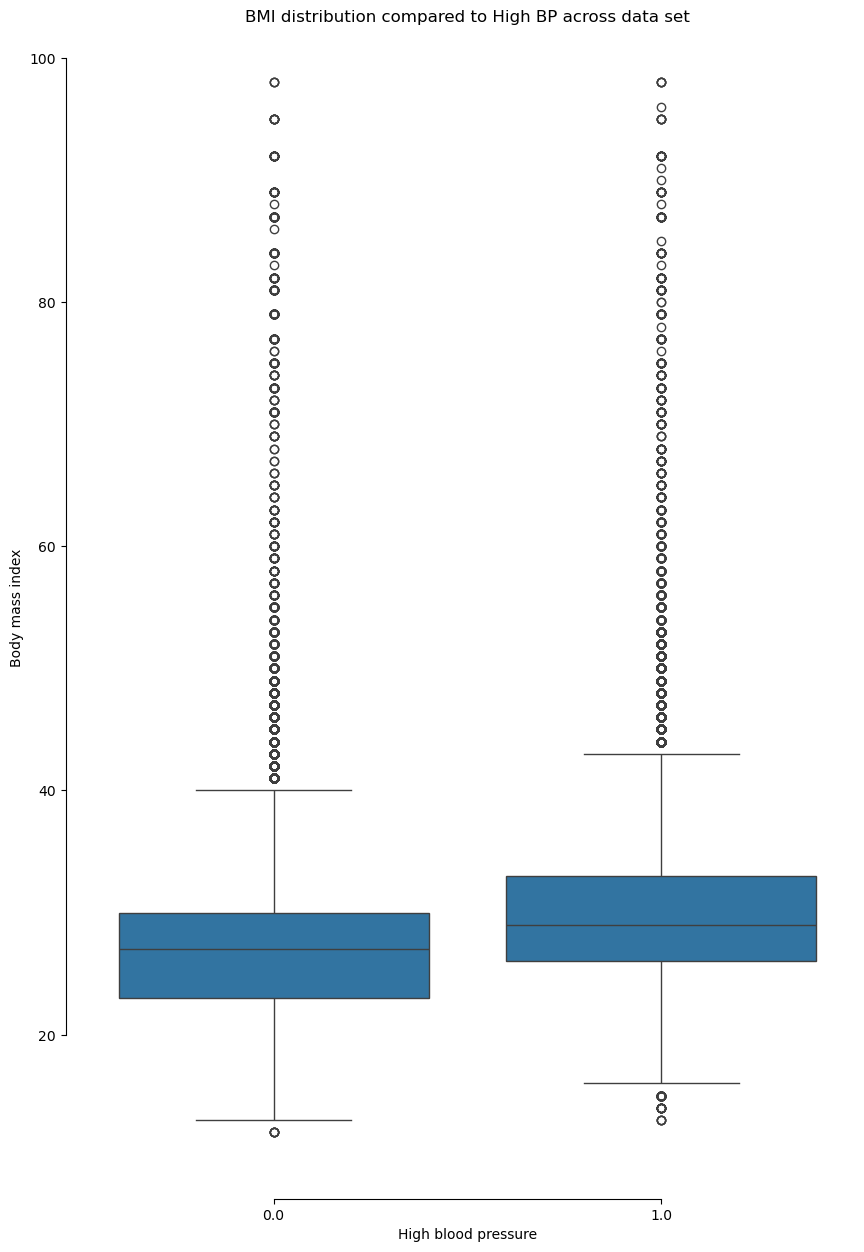

In [30]:
#box plots:
plt.figure(figsize=(10,15))
sns.boxplot(x='HighBP', y='BMI', data=df)
sns.despine(offset=10, trim=True) 
plt.title("BMI distribution compared to High BP across data set") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('High blood pressure')
plt.ylabel('Body mass index')

**OBSERVATION**

 This box plot shows participants with and without high blood pressure compared to BMI, 
 According to the plot, individuals with High blood pressure seem to have a higher BMI.
 This may indicate that there is a statistically significant relationship between BMI and blood pressure.
 The Q2 of those without High BP is a tad lower than that of those with high BP.
 those without high BP seem left skewed, and those with high BP seem right skewed.

1st site used for reference: https://seaborn.pydata.org/examples/grouped_boxplot.html
 2nd site used: https://stackoverflow.com/questions/35131798/tweaking-seaborn-boxplot

--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'Physical Health')

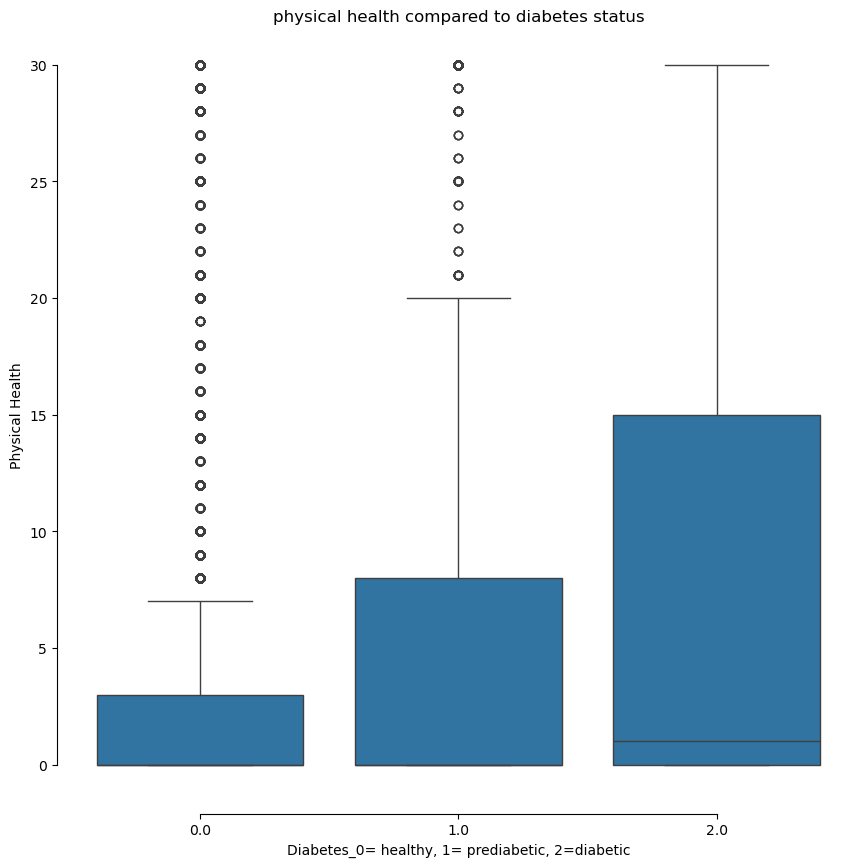

In [31]:
plt.figure(figsize=(10,10))
sns.boxplot(x='Diabetes_012', y='PhysHlth', data=df)
sns.despine(offset=10, trim=True)
plt.title("physical health compared to diabetes status") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('Diabetes_0= healthy, 1= prediabetic, 2=diabetic')
plt.ylabel('Physical Health')

 This box plot shows participants who don't have diabetes, those who do, and those who are pre diabetic and their Physical health in prior  days.
 those without and those who are pre diabetic have a low median, compared to those who have diabetes.
 indicating that those with diabetes have experienced more days of poor health conditions than the rest
 all three boxes of those with and without and pre diabetic are right skewed.
 each box has a decent amount of individuals who experienced poor physical health days. The box 
 of those with diabetes doesn't have outliers but I assume that is because those with diabetes
 all experience poor health days to some extent, making the outliers less extreme.
 this supports my question and will help me and others gain a deeper understanding of my research question
 by examining phy health quality days and using that to examine cardiovascular health.

--------------------------------------------------------------------------------------------------------------------------







Text(0, 0.5, 'Heart Disease Rate')

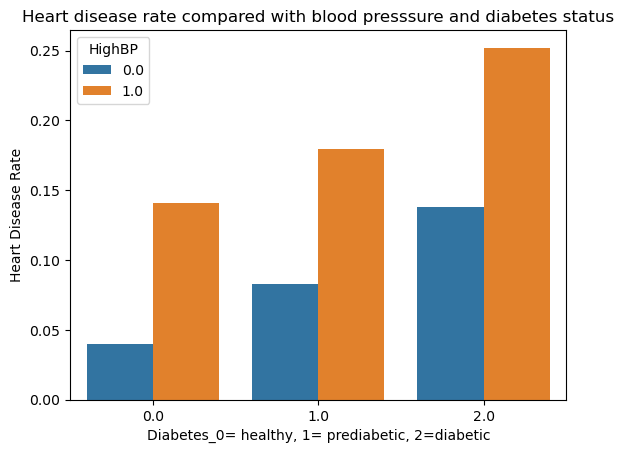

In [32]:
# bar charts
averageOne = df.groupby(['Diabetes_012', 'HighBP'])['HeartDiseaseorAttack'].mean().reset_index(name='HeartDiseaseRate')
sns.barplot(x=averageOne['Diabetes_012'], y=averageOne['HeartDiseaseRate'], hue=averageOne['HighBP'])
plt.title("Heart disease rate compared with blood presssure and diabetes status") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('Diabetes_0= healthy, 1= prediabetic, 2=diabetic')
plt.ylabel('Heart Disease Rate')

 This bar chart shows the relationship of those with, without and pre diabetic indivduals along with their
 blood pressure and their rate of heart disease.
 The rate of heart disease increases across not diabetic pre diabetic and diabetic in that order, 
 this shows a upward trend.
 This also reflects a relationship stating that heart risks have a meaningful association with diabetes.
 this matters in my project because it supports my research question of in what ways does a 
 history of cardiovascular risk factors, such as high blood pressure, high cholesterol, and heart disease, 
 affect the likelihood of an individual being diagnosed with diabetes

--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'High cholesterol rate')

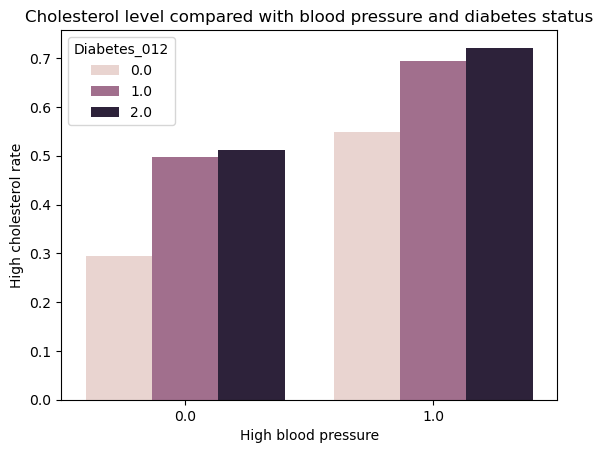

In [33]:
averageTwo = df.groupby(['HighBP', 'Diabetes_012'])['HighChol'].mean().reset_index(name='HighCholRate')
sns.barplot(x=averageTwo['HighBP'], y=averageTwo['HighCholRate'], hue=averageTwo['Diabetes_012'])
plt.title("Cholesterol level compared with blood pressure and diabetes status") # used for help: https://matplotlib.org/stable/tutorials/pyplot.html
plt.xlabel('High blood pressure')
plt.ylabel('High cholesterol rate')

 Note: Hue gives me the bars based on the staus 0, 1 and 2.. healthy pre diabetic, and diabetic
 sites used for help: https://seaborn.pydata.org/generated/seaborn.barplot.html
 2nd site used: https://www.geeksforgeeks.org/python/grouped-barplots-in-python-with-seaborn/avg_bmi = df.groupby('Age')['BMI'].mean().reset_index(name='AvgBMI')


 This bar chart shows the rate of high cholesterol for those with and without high blood pressure, 
 and whether they have diabetes(with, without, diabetic). 
 Individuals with high blood pressure trend upwards just as those without.
 This suggests that high blood pressure and high cholesterol have a statistical significance, 
 which is relevant to my research question because both are cardiovascular risk factors 
 associated with whether someone has or doesn't have diabetes.

--------------------------------------------------------------------------------------------------------------------------






Text(0, 0.5, 'Density')

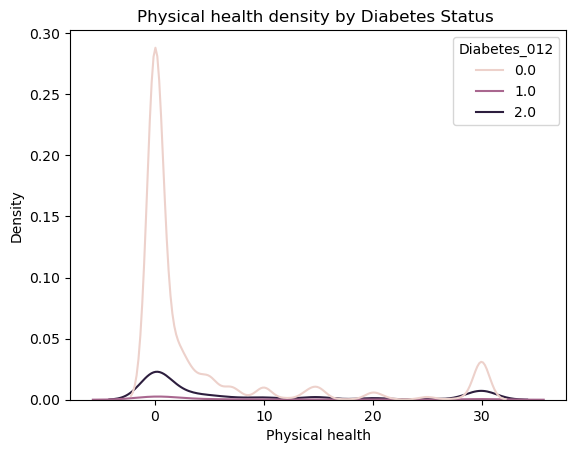

In [34]:
# https://seaborn.pydata.org/examples/index.html
#https://seaborn.pydata.org/generated/seaborn.kdeplot.html

sns.kdeplot(data=df, x='PhysHlth', hue='Diabetes_012')
plt.title('Physical health density by Diabetes Status ')
plt.xlabel('Physical health')
plt.ylabel('Density')

 This KDE chart shows the density of physical health in those with their diabetes status.
 This chart is right-skewed, and all have a decent rise at 0 especially for those that dont have diabetes.
 The zero indicates no bad health days.
 The lines representing pre diabetic and diabetic are much lower indicating a larger spread of individuals that experience poor health days
 This graph supports my question, by showing clearly how diabetes possibly affects physical health and the other graphs will help me link phys health to cardiovascular health.

--------------------------------------------------------------------------------------------------------------------------




